# Skin Lesion Classification — Dual-Branch ResNet50 with Cross-Attention

**Research-grade notebook.** Single best model using:
- **Same preprocessing** as `thesis.ipynb` (Derm7pt + MILK10k, 5 classes, stratified 70/15/15)
- **Dual-branch ResNet50** (clinical photo + dermoscopic photo)
- **Unidirectional Q,K,V cross-attention** fusion (clinical = Q queries dermoscopic K,V)
- **Optuna** hyperparameter tuning (20 trials, TPE sampler)
- **Early stopping** (patience=7, monitor val_loss)
- Full evaluation + visualization (attention maps, ROC, PR, confusion matrix)

---

## 1. Setup & Imports

In [1]:
import os, copy, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization.matplotlib as optuna_vis

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_score, recall_score, accuracy_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, average_precision_score, log_loss
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True   # faster conv on fixed input sizes
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'Optuna:  {optuna.__version__}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

/Users/christianluisefendy/.pyenv/versions/3.8.10/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
PyTorch: 2.4.1
Optuna:  4.5.0


## 2. Data Loading & Preprocessing

We merge two datasets:
- **Derm7pt**: 1,011 paired clinical + dermoscopic images, 20 fine-grained diagnoses
- **MILK10k**: 5,240 lesions, 11 classes, subset mapped to same 5-class scheme

Both are mapped to 5 standard classes: **MEL**, **NV**, **BCC**, **SK**, **MISC**.

In [2]:
# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()

clinic_ok = derm_df['clinic_path'].apply(lambda x: Path(x).exists()).sum()
derm_ok   = derm_df['derm_path'].apply(lambda x: Path(x).exists()).sum()
print(f'Derm7pt: {len(derm_df)} samples | clinic ok: {clinic_ok} | derm ok: {derm_ok}')

Derm7pt: 1011 samples | clinic ok: 1011 | derm ok: 1011


In [3]:
# ── Diagnosis grouping: 20 → 5 classes ───────────────────────────────────────
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}
print('Classes:', class_names)
print('Label map:', label_map)
print()
print(derm_df['diagnosis_group'].value_counts())

Classes: ['BCC', 'MEL', 'MISC', 'NV', 'SK']
Label map: {'BCC': 0, 'MEL': 1, 'MISC': 2, 'NV': 3, 'SK': 4}

diagnosis_group
NV      575
MEL     252
MISC     97
SK       45
BCC      42
Name: count, dtype: int64


In [4]:
# ── MILK10k ───────────────────────────────────────────────────────────────────
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')

milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}

gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)

clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')

milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

print(f'MILK10k: {len(milk_df)} lesions | classes:')
print(milk_df['diagnosis_group'].value_counts())

MILK10k: 4361 lesions | classes:
diagnosis_group
BCC     2522
NV       746
SK       544
MEL      450
MISC      99
Name: count, dtype: int64


In [5]:
# ── Combine Derm7pt + MILK10k ─────────────────────────────────────────────────
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'

combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True
)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

print(f'Combined: {len(df)} samples | {len(class_names)} classes')
print()
print(df['diagnosis_group'].value_counts())
print()
print(df['source'].value_counts())

Combined: 5372 samples | 5 classes

diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196
Name: count, dtype: int64

source
MILK10k    4361
Derm7pt    1011
Name: count, dtype: int64


## 3. Exploratory Data Analysis

Quick look at class and source distributions, plus sample paired images.

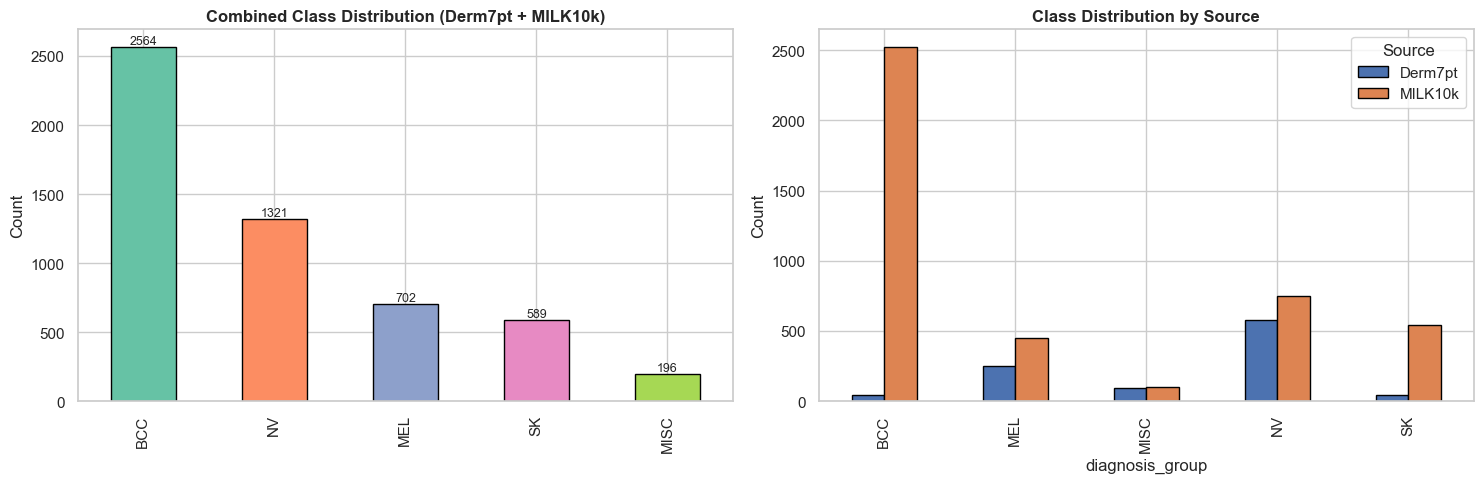

Class imbalance ratio (max/min): 13.1 ×


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

counts = df['diagnosis_group'].value_counts()
counts.plot(kind='bar', color=sns.color_palette('Set2', len(counts)),
            edgecolor='black', ax=axes[0])
axes[0].set_title('Combined Class Distribution (Derm7pt + MILK10k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

df.groupby(['source', 'diagnosis_group']).size().unstack(fill_value=0).T.plot(
    kind='bar', ax=axes[1], edgecolor='black', color=['#4C72B0', '#DD8452'])
axes[1].set_title('Class Distribution by Source', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend(title='Source')

plt.tight_layout()
plt.show()

# Class imbalance summary
print('Class imbalance ratio (max/min):', round(counts.max() / counts.min(), 1), '×')

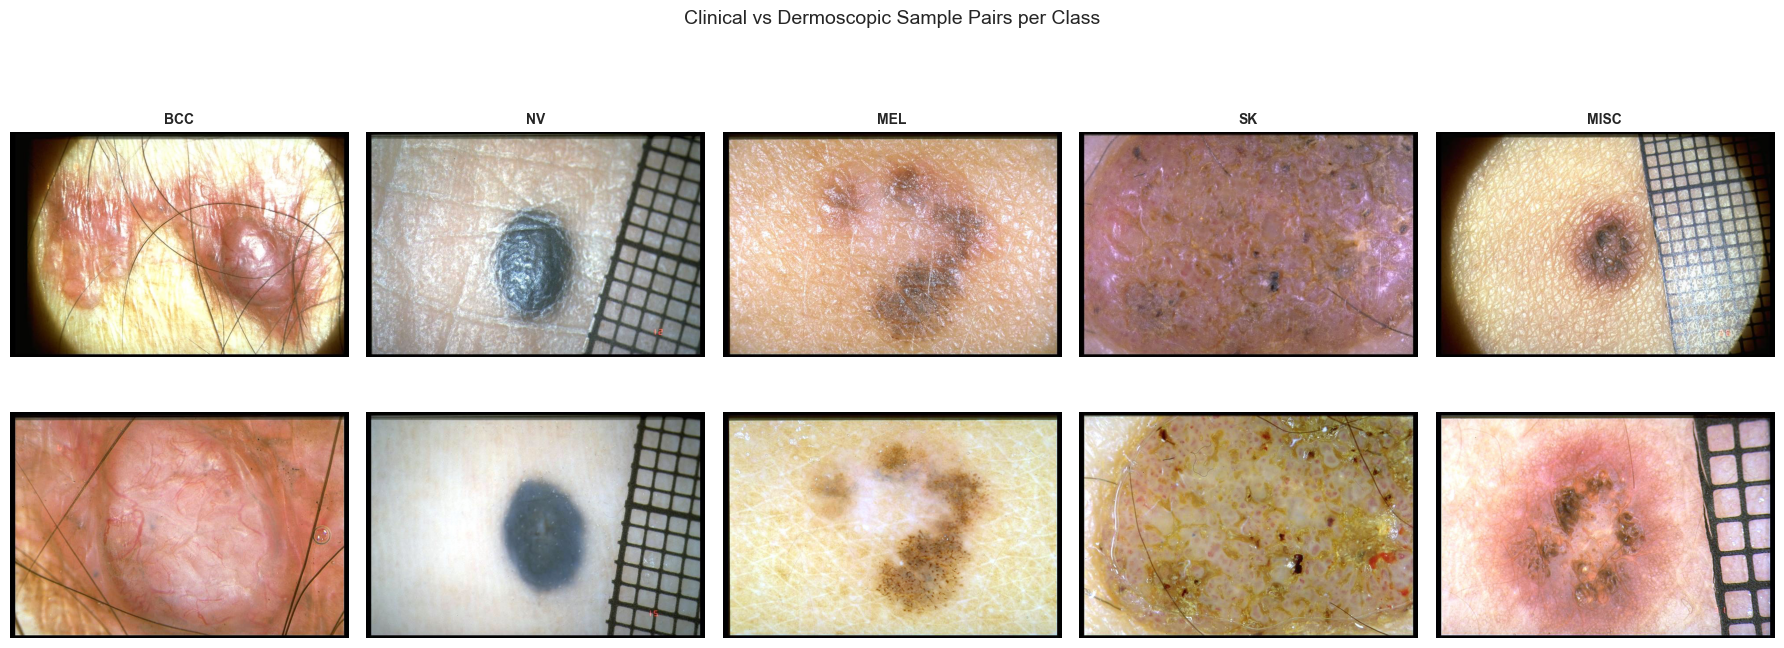

In [7]:
# Sample paired images per class
top5 = df['diagnosis_group'].value_counts().index.tolist()[:5]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for j, cls in enumerate(top5):
    sample = df[df['diagnosis_group'] == cls].iloc[0]
    axes[0, j].imshow(Image.open(sample['clinic_path']))
    axes[0, j].set_title(cls, fontsize=10, fontweight='bold')
    axes[0, j].axis('off')
    axes[1, j].imshow(Image.open(sample['derm_path']))
    axes[1, j].axis('off')
axes[0, 0].set_ylabel('Clinical', fontsize=12)
axes[1, 0].set_ylabel('Dermoscopic', fontsize=12)
plt.suptitle('Clinical vs Dermoscopic Sample Pairs per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Dataset & DataLoaders

Stratified 70/15/15 train/val/test split.
Class imbalance handled via `WeightedRandomSampler` (training) and weighted `CrossEntropyLoss`.

In [8]:
class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

In [9]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Stratified split ──────────────────────────────────────────────────────────
labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

# ── Class weights ─────────────────────────────────────────────────────────────
train_labels  = labels[train_idx]
class_counts  = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
sampler       = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
loss_weights  = torch.tensor(
    [len(train_labels) / (len(class_names) * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print('Loss weights:', dict(zip(class_names, loss_weights.cpu().numpy().round(3))))

Train: 3760 | Val: 806 | Test: 806
Loss weights: {'BCC': 0.419, 'MEL': 1.532, 'MISC': 5.489, 'NV': 0.813, 'SK': 1.825}


In [10]:
# ── DataLoader config (device-aware) ─────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size=32):
    """Build train/val/test DataLoaders. Called inside Optuna objective with varying batch_size."""
    train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
    val_ds   = SkinLesionDualDataset(df.iloc[val_idx],   val_transform)
    test_ds  = SkinLesionDualDataset(df.iloc[test_idx],  val_transform)
    samp = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

train_loader, val_loader, test_loader, test_ds = make_loaders(batch_size=32)
print('Loaders ready.')

Loaders ready.


## 5. Model Architecture — Dual-Branch ResNet50 + Cross-Attention Fusion

### Design

```
Clinical photo  → ResNet50_A → feature maps [B, 2048, 7, 7]  ─→ Q [B, 49, embed_dim]
                                                                          ↓
                                                               CrossAttention → fused [B, embed_dim]
                                                                          ↑
Dermoscopic photo → ResNet50_B → feature maps [B, 2048, 7, 7] ─→ K, V [B, 49, embed_dim]

fused → Linear(embed_dim → embed_dim//2) → BN → ReLU → Dropout → Linear(embed_dim//2 → 5)
```

**Why cross-attention instead of concat?**
Concatenation treats all spatial positions equally. Cross-attention lets the clinical branch
*selectively query* relevant regions of the dermoscopic features — mirroring how a
dermatologist uses the naked-eye view to guide where to look on the dermoscope.

In [11]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

    def forward(self, x):
        return self.features(x)

In [12]:
class CrossAttentionFusion(nn.Module):
    """
    Unidirectional cross-attention: clinical branch queries dermoscopic branch.
      Q  ← projected clinical features    [B, 49, embed_dim]
      K,V ← projected dermoscopic features [B, 49, embed_dim]

    Adds residual connection + LayerNorm + position-wise FFN (Transformer block style).
    Returns fused vector [B, embed_dim] and attention weights for visualization.
    """
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, 'embed_dim must be divisible by num_heads'
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)

    def forward(self, clinic_feat, derm_feat):
        # Reshape spatial maps → token sequences
        c = clinic_feat.flatten(2).transpose(1, 2)   # [B, 49, 2048]
        d = derm_feat.flatten(2).transpose(1, 2)     # [B, 49, 2048]

        Q = self.q_proj(c)  # [B, 49, embed_dim]
        K = self.k_proj(d)  # [B, 49, embed_dim]
        V = self.v_proj(d)  # [B, 49, embed_dim]

        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        # attn_weights: [B, 49, 49] — rows = clinic positions, cols = derm positions

        x = self.norm1(Q + attn_out)     # residual + LayerNorm
        x = self.norm2(x + self.ffn(x)) # FFN + residual + LayerNorm

        # Global average pool over token sequence → [B, embed_dim]
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights

In [13]:
class DualBranchCrossAttn(nn.Module):
    """
    Full dual-branch model with cross-attention fusion.
    Accepts embed_dim and num_heads as hyperparameters (tuned via Optuna).
    """
    def __init__(self, num_classes=5, embed_dim=512, num_heads=8, dropout=0.2):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=True)
        self.resnet_derm   = ResNet50Backbone(pretrained=True)
        self.fusion        = CrossAttentionFusion(
            in_dim=2048, embed_dim=embed_dim, num_heads=num_heads, dropout=dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def _freeze_backbones(self):
        """Freeze layers 1-3; keep layer4 trainable for warm-up phase."""
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():  # layer4
                p.requires_grad = True

    def unfreeze_resnets(self):
        """Unfreeze layer3 after warm-up."""
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():  # layer3
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)  # [B, 2048, 7, 7]
        feat_d = self.resnet_derm(derm_img)      # [B, 2048, 7, 7]
        fused, attn_weights = self.fusion(feat_c, feat_d)
        logits = self.classifier(fused)
        return logits, attn_weights

# ── Quick sanity check ────────────────────────────────────────────────────────
_m = DualBranchCrossAttn(num_classes=5, embed_dim=512, num_heads=8).to(device)
_m._freeze_backbones()
with torch.no_grad():
    _c = torch.randn(2, 3, 224, 224).to(device)
    _d = torch.randn(2, 3, 224, 224).to(device)
    _logits, _attn = _m(_c, _d)
print(f'Logits shape:          {_logits.shape}')   # [2, 5]
print(f'Attention weights:     {_attn.shape}')     # [2, 49, 49]
total  = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Parameters:            {total:,} total | {trainable:,} trainable ({trainable/total*100:.1f}%)')
del _m

Logits shape:          torch.Size([2, 5])
Attention weights:     torch.Size([2, 49, 49])
Parameters:            52,399,237 total | 35,312,645 trainable (67.4%)


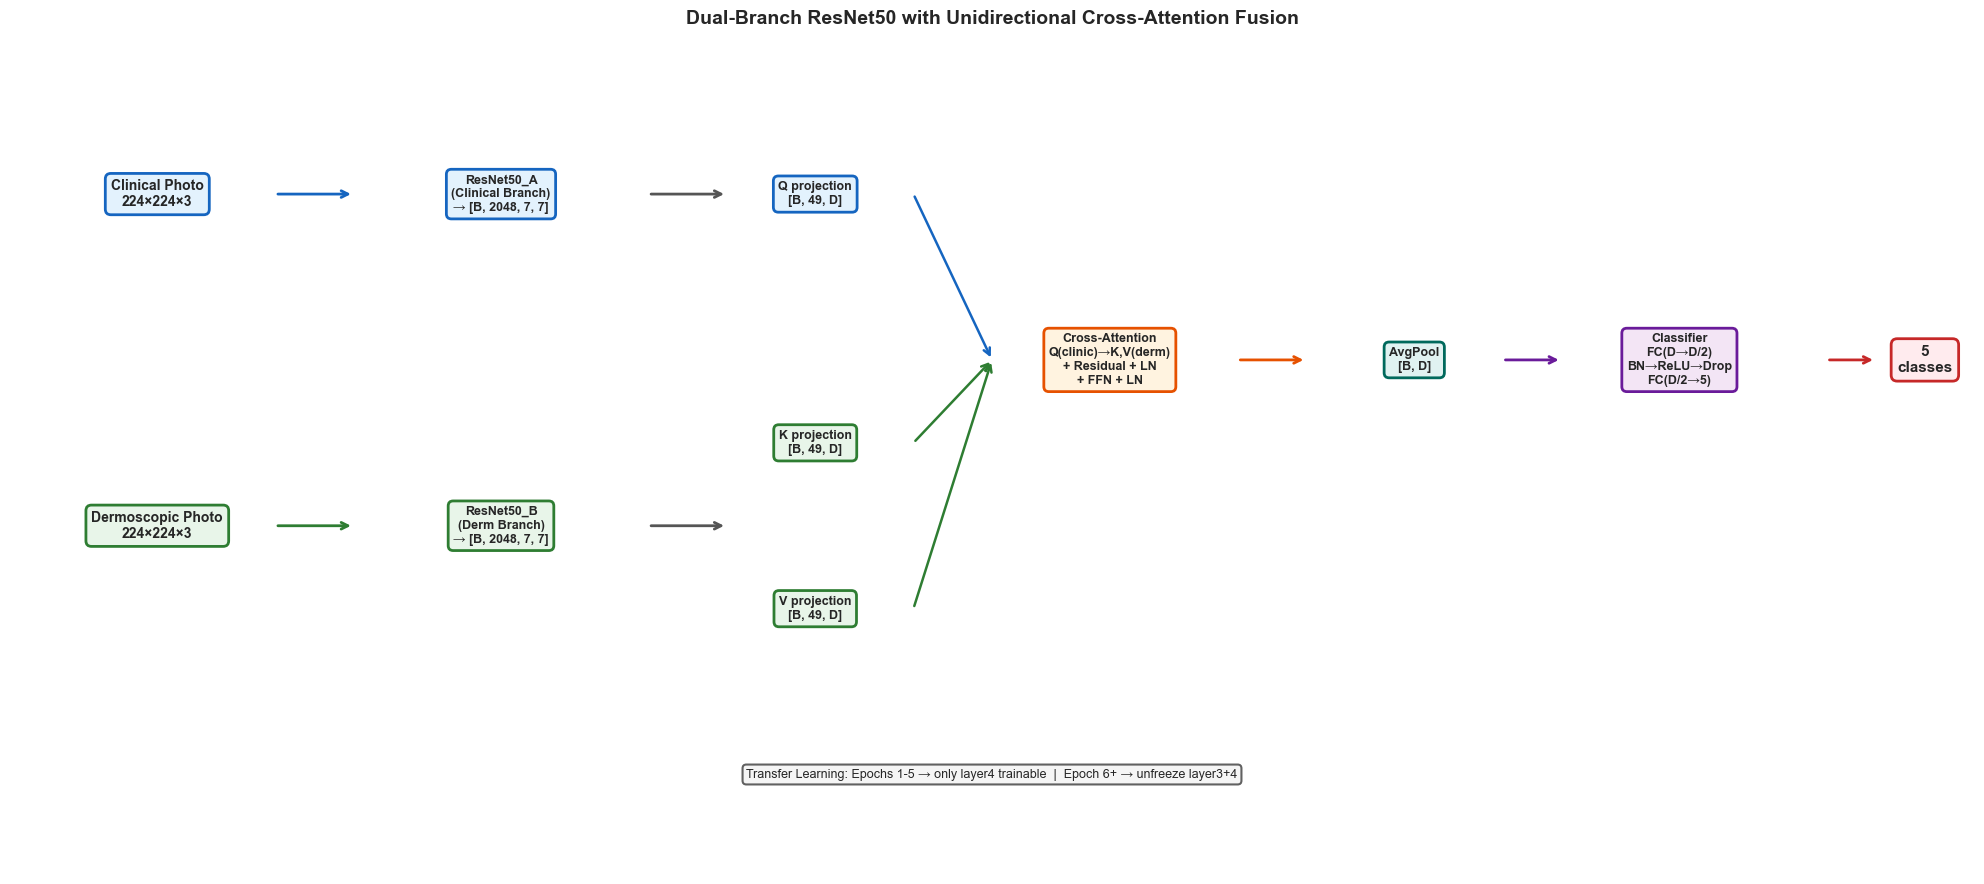

In [14]:
# ── Architecture diagram ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 9))
ax.set_xlim(0, 20); ax.set_ylim(0, 10); ax.axis('off')

b_blue   = dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
b_green  = dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)
b_orange = dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', edgecolor='#E65100', linewidth=2)
b_purple = dict(boxstyle='round,pad=0.4', facecolor='#F3E5F5', edgecolor='#6A1B9A', linewidth=2)
b_red    = dict(boxstyle='round,pad=0.4', facecolor='#FFEBEE', edgecolor='#C62828', linewidth=2)
b_teal   = dict(boxstyle='round,pad=0.4', facecolor='#E0F2F1', edgecolor='#00695C', linewidth=2)
b_gray   = dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', edgecolor='#616161', linewidth=1.5)

ax.text(1.5, 8.2, 'Clinical Photo\n224×224×3',       ha='center', va='center', fontsize=10, fontweight='bold', bbox=b_blue)
ax.text(1.5, 4.2, 'Dermoscopic Photo\n224×224×3',    ha='center', va='center', fontsize=10, fontweight='bold', bbox=b_green)

ax.annotate('', xy=(3.5, 8.2), xytext=(2.7, 8.2), arrowprops=dict(arrowstyle='->', lw=2, color='#1565C0'))
ax.annotate('', xy=(3.5, 4.2), xytext=(2.7, 4.2), arrowprops=dict(arrowstyle='->', lw=2, color='#2E7D32'))

ax.text(5.0, 8.2, 'ResNet50_A\n(Clinical Branch)\n→ [B, 2048, 7, 7]',  ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_blue)
ax.text(5.0, 4.2, 'ResNet50_B\n(Derm Branch)\n→ [B, 2048, 7, 7]', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_green)

ax.annotate('', xy=(7.3, 8.2), xytext=(6.5, 8.2), arrowprops=dict(arrowstyle='->', lw=2, color='#555'))
ax.annotate('', xy=(7.3, 4.2), xytext=(6.5, 4.2), arrowprops=dict(arrowstyle='->', lw=2, color='#555'))

ax.text(8.2, 8.2, 'Q projection\n[B, 49, D]', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_blue)
ax.text(8.2, 5.2, 'K projection\n[B, 49, D]', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_green)
ax.text(8.2, 3.2, 'V projection\n[B, 49, D]', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_green)

ax.annotate('', xy=(10.0, 6.2), xytext=(9.2, 8.2), arrowprops=dict(arrowstyle='->', lw=1.8, color='#1565C0'))
ax.annotate('', xy=(10.0, 6.2), xytext=(9.2, 5.2), arrowprops=dict(arrowstyle='->', lw=1.8, color='#2E7D32'))
ax.annotate('', xy=(10.0, 6.2), xytext=(9.2, 3.2), arrowprops=dict(arrowstyle='->', lw=1.8, color='#2E7D32'))

ax.text(11.2, 6.2, 'Cross-Attention\nQ(clinic)→K,V(derm)\n+ Residual + LN\n+ FFN + LN', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_orange)

ax.annotate('', xy=(13.2, 6.2), xytext=(12.5, 6.2), arrowprops=dict(arrowstyle='->', lw=2, color='#E65100'))

ax.text(14.3, 6.2, 'AvgPool\n[B, D]', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_teal)

ax.annotate('', xy=(15.8, 6.2), xytext=(15.2, 6.2), arrowprops=dict(arrowstyle='->', lw=2, color='#6A1B9A'))

ax.text(17.0, 6.2, 'Classifier\nFC(D→D/2)\nBN→ReLU→Drop\nFC(D/2→5)', ha='center', va='center', fontsize=9, fontweight='bold', bbox=b_purple)

ax.annotate('', xy=(19.0, 6.2), xytext=(18.5, 6.2), arrowprops=dict(arrowstyle='->', lw=2, color='#C62828'))
ax.text(19.5, 6.2, '5\nclasses', ha='center', va='center', fontsize=11, fontweight='bold', bbox=b_red)

ax.text(10.0, 1.2,
    'Transfer Learning: Epochs 1-5 → only layer4 trainable  |  Epoch 6+ → unfreeze layer3+4',
    ha='center', va='center', fontsize=9, bbox=b_gray)

ax.set_title('Dual-Branch ResNet50 with Unidirectional Cross-Attention Fusion',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 6. Training Helpers

Reusable functions for both Optuna search (short trials) and final training (full epochs).

In [15]:
class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs.
    Restores best weights when triggered.
    """
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [16]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total

## 7. Hyperparameter Search — Optuna (20 trials)

**Search space:**

| Parameter | Range |
|-----------|-------|
| `lr` | log-uniform [1e-5, 1e-2] |
| `dropout` | uniform [0.1, 0.5] |
| `num_heads` | categorical {2, 4, 8} |
| `embed_dim` | categorical {256, 512, 1024} |
| `weight_decay` | log-uniform [1e-6, 1e-3] |
| `batch_size` | categorical {16, 32, 64} |

Each trial trains for **10 epochs** (short budget for search). Objective: maximize **validation macro-F1**.
`MedianPruner` kills underperforming trials early (saves time).

> **Runtime estimate on MPS:** ~20–40 min total (20 trials × ~1–2 min each).

In [17]:
OPTUNA_EPOCHS   = 10   # short per-trial budget
UNFREEZE_EPOCH  = 5    # unfreeze layer3 after this epoch (same as thesis.ipynb)
N_TRIALS        = 20

def objective(trial):
    # ── Suggest hyperparameters ──────────────────────────────────────────────
    lr           = trial.suggest_float('lr',           1e-5, 1e-2, log=True)
    dropout      = trial.suggest_float('dropout',      0.1,  0.5)
    num_heads    = trial.suggest_categorical('num_heads',  [2, 4, 8])
    embed_dim    = trial.suggest_categorical('embed_dim',  [256, 512, 1024])
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [16, 32, 64])

    # embed_dim must be divisible by num_heads
    if embed_dim % num_heads != 0:
        raise optuna.TrialPruned()

    tr_loader, va_loader, _, _ = make_loaders(batch_size)

    model     = DualBranchCrossAttn(num_classes=len(class_names),
                                    embed_dim=embed_dim,
                                    num_heads=num_heads,
                                    dropout=dropout).to(device)
    model._freeze_backbones()
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=lr, weight_decay=weight_decay)

    best_f1 = 0.0
    for epoch in range(OPTUNA_EPOCHS):
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_resnets()
            optimizer = optim.Adam(model.parameters(), lr=lr / 2, weight_decay=weight_decay)

        train_one_epoch(model, tr_loader, optimizer, criterion)
        val_loss, _ = validate(model, va_loader, criterion)

        # Quick F1 on val set for objective
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for c, d, lb in va_loader:
                logits, _ = model(c.to(device), d.to(device))
                preds.extend(logits.argmax(1).cpu().numpy())
                trues.extend(lb.numpy())
        val_f1 = f1_score(trues, preds, average='macro', zero_division=0)
        best_f1 = max(best_f1, val_f1)

        trial.report(val_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_f1


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=3),
)

print(f'Starting Optuna search ({N_TRIALS} trials, {OPTUNA_EPOCHS} epochs each)...')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nBest trial: #{study.best_trial.number}')
print(f'Best val macro-F1: {study.best_value:.4f}')
print('Best hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Starting Optuna search (20 trials, 10 epochs each)...


Best trial: 0. Best value: 0.593688:   5%|▌         | 1/20 [40:36<12:51:38, 2436.74s/it]


[W 2026-05-06 15:52:13,088] Trial 1 failed with parameters: {'lr': 0.00314288089084011, 'dropout': 0.18493564427131048, 'num_heads': 8, 'embed_dim': 256, 'weight_decay': 6.847920095574779e-05, 'batch_size': 64} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/christianluisefendy/.pyenv/versions/3.8.10/lib/python3.8/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/hy/rtkj7_ms0yb77p07f6t4tmzr0000gn/T/ipykernel_73434/1650301778.py", line 35, in objective
    train_one_epoch(model, tr_loader, optimizer, criterion)
  File "/var/folders/hy/rtkj7_ms0yb77p07f6t4tmzr0000gn/T/ipykernel_73434/381683619.py", line 4, in train_one_epoch
    for clinic_imgs, derm_imgs, labels_batch in loader:
  File "/Users/christianluisefendy/.pyenv/versions/3.8.10/lib/python3.8/site-packages/torch/utils/data/dataloader.py", line 630, in __next__
    data = self._next_data()
  File "/Users/ch

KeyboardInterrupt: 

In [ ]:
# ── Optuna study visualizations ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
ax = axes[0]
vals  = [t.value for t in study.trials if t.value is not None]
trial_nums = [t.number for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
ax.scatter(trial_nums, vals, alpha=0.6, label='Trial F1', color='steelblue')
ax.plot(trial_nums, best_so_far, color='darkorange', linewidth=2, label='Best so far')
ax.set_title('Optuna — Optimization History', fontweight='bold')
ax.set_xlabel('Trial'); ax.set_ylabel('Val Macro-F1')
ax.legend()

# Parameter importances
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = list(importances.keys())[::-1]
    vals_sorted   = [importances[p] for p in params_sorted]
    axes[1].barh(params_sorted, vals_sorted, color=sns.color_palette('Set2', len(params_sorted)),
                edgecolor='black')
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
    axes[1].set_xlabel('Importance')
except Exception:
    axes[1].text(0.5, 0.5, 'Not enough trials\nfor importance', ha='center', va='center',
                transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

# Save Optuna study
with open('optuna_study.pkl', 'wb') as f:
    pickle.dump(study, f)
print('Saved: optuna_study.pkl')

## 8. Final Training with Best Hyperparameters

Using `study.best_params`, train a fresh model for up to **30 epochs** with:
- Staged unfreezing at epoch 5 (layer3+layer4)
- `StepLR` scheduler (step=10, γ=0.5)
- `EarlyStopping` (patience=7, restore best weights)

In [ ]:
best_params = study.best_params
print('Training with:', best_params)

FINAL_EPOCHS   = 30
PATIENCE       = 7
UNFREEZE_EPOCH = 5

tr_loader, va_loader, te_loader, test_ds = make_loaders(best_params['batch_size'])

model = DualBranchCrossAttn(
    num_classes=len(class_names),
    embed_dim  =best_params['embed_dim'],
    num_heads  =best_params['num_heads'],
    dropout    =best_params['dropout'],
).to(device)
model._freeze_backbones()

criterion     = nn.CrossEntropyLoss(weight=loss_weights)
optimizer     = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           =best_params['lr'],
    weight_decay =best_params['weight_decay'],
)
scheduler     = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
early_stop    = EarlyStopping(patience=PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stop_epoch = None
start = time.time()

for epoch in range(FINAL_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_resnets()
        optimizer = optim.Adam(
            model.parameters(),
            lr           =best_params['lr'] / 2,
            weight_decay =best_params['weight_decay'],
        )
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
        print(f'  Epoch {epoch+1}: unfroze layer3+layer4, lr → {best_params["lr"]/2:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion)
    va_loss, va_acc = validate(model, va_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    early_stop(va_loss, model)
    lr_now = optimizer.param_groups[0]['lr']
    print(f'  Epoch {epoch+1:2d}/{FINAL_EPOCHS} | '
          f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
          f'lr {lr_now:.2e} | es_count {early_stop.counter}/{PATIENCE}')

    if early_stop.stop:
        early_stop_epoch = epoch + 1
        print(f'\nEarly stopping at epoch {early_stop_epoch}. Restoring best weights.')
        early_stop.restore(model)
        break

elapsed = (time.time() - start) / 60
print(f'\nTraining done in {elapsed:.1f} min | best val loss: {early_stop.best_loss:.4f}')

with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)
print('Saved: training_history.pkl')

In [ ]:
# Save best model
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names'     : class_names,
    'label_map'       : label_map,
    'best_params'     : best_params,
    'training_history': history,
    'early_stop_epoch': early_stop_epoch,
    'best_val_loss'   : early_stop.best_loss,
}, 'model_best.pth')
print('Saved: model_best.pth')

## 9. Evaluation on Test Set

Full evaluation on held-out test set (806 samples, never seen during training or Optuna search).

In [ ]:
model.eval()
all_preds, all_labels, all_probs, all_attn = [], [], [], []

with torch.no_grad():
    for clinic_imgs, derm_imgs, labels_batch in te_loader:
        clinic_imgs = clinic_imgs.to(device)
        derm_imgs   = derm_imgs.to(device)
        logits, attn_weights = model(clinic_imgs, derm_imgs)
        probs = F.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels_batch.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_attn.extend(attn_weights.cpu().numpy())  # [B, 49, 49]

y_true  = np.array(all_labels)
y_pred  = np.array(all_preds)
y_probs = np.array(all_probs)
y_attn  = np.array(all_attn)   # [N, 49, 49]

# ── Aggregate metrics ─────────────────────────────────────────────────────────
metrics = {
    'accuracy'         : accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'precision_macro'  : precision_score(y_true, y_pred, average='macro',    zero_division=0),
    'recall_macro'     : recall_score(y_true, y_pred,    average='macro',    zero_division=0),
    'f1_macro'         : f1_score(y_true, y_pred,        average='macro',    zero_division=0),
    'f1_weighted'      : f1_score(y_true, y_pred,        average='weighted', zero_division=0),
    'cohen_kappa'      : cohen_kappa_score(y_true, y_pred),
    'mcc'              : matthews_corrcoef(y_true, y_pred),
    'log_loss'         : log_loss(y_true, y_probs),
}

print('=' * 52)
print('  TEST RESULTS')
print('=' * 52)
for k, v in metrics.items():
    print(f'  {k:<20}: {v:.4f}')
print('=' * 52)
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

In [ ]:
# ── Per-class metrics table ───────────────────────────────────────────────────
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
cm = confusion_matrix(y_true, y_pred)

per_prec  = precision_score(y_true, y_pred, average=None, zero_division=0)
per_rec   = recall_score(y_true, y_pred,    average=None, zero_division=0)
per_f1    = f1_score(y_true, y_pred,        average=None, zero_division=0)
per_auc, per_ap, per_spec = [], [], []

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    per_auc.append(auc(fpr, tpr))
    per_ap.append(average_precision_score(y_true_bin[:, i], y_probs[:, i]))
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    per_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

results_df = pd.DataFrame({
    'Class'      : class_names,
    'Precision'  : per_prec.round(4),
    'Recall'     : per_rec.round(4),
    'Specificity': np.array(per_spec).round(4),
    'F1'         : per_f1.round(4),
    'AUC'        : np.array(per_auc).round(4),
    'AP'         : np.array(per_ap).round(4),
    'Support'    : np.bincount(y_true),
})
macro_row = pd.DataFrame([{
    'Class': 'Macro Avg', 'Precision': per_prec.mean().round(4),
    'Recall': per_rec.mean().round(4), 'Specificity': np.mean(per_spec).round(4),
    'F1': per_f1.mean().round(4), 'AUC': np.mean(per_auc).round(4),
    'AP': np.mean(per_ap).round(4), 'Support': len(y_true),
}])
results_df = pd.concat([results_df, macro_row], ignore_index=True)
display(results_df)

# Save
eval_payload = {
    'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs,
    'class_names': class_names, 'metrics': metrics,
    'confusion_matrix': cm, 'confusion_matrix_normalized': confusion_matrix(y_true, y_pred, normalize='true'),
}
with open('evaluation_results.pkl', 'wb') as f:
    pickle.dump(eval_payload, f)
results_df.to_csv('per_class_results.csv', index=False)
print('Saved: evaluation_results.pkl, per_class_results.csv')

## 10. Visualizations

Full research-grade visualization suite:
1. Training curves with early-stop marker
2. Confusion matrices (counts + normalized)
3. Per-class F1 bar chart
4. ROC curves per class
5. Precision-Recall curves per class
6. Attention map visualization
7. Sample correct vs incorrect predictions

In [ ]:
# ── 10.1 Training curves ──────────────────────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tr_key, va_key, title in [
    (axes[0], 'train_loss', 'val_loss',  'Loss'),
    (axes[1], 'train_acc',  'val_acc',   'Accuracy'),
]:
    ax.plot(epochs_range, history[tr_key], 'b-o', markersize=4, label='Train')
    ax.plot(epochs_range, history[va_key], 'r-o', markersize=4, label='Val')
    if early_stop_epoch:
        ax.axvline(x=early_stop_epoch, color='gray', linestyle='--', alpha=0.7,
                   label=f'Early stop (ep {early_stop_epoch})')
    ax.axvline(x=UNFREEZE_EPOCH + 1, color='green', linestyle=':', alpha=0.6,
               label=f'Unfreeze (ep {UNFREEZE_EPOCH+1})')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Training Curves — Final Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 10.2 Confusion matrices ───────────────────────────────────────────────────
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

In [ ]:
# ── 10.3 Per-class F1 + ROC + Precision-Recall ────────────────────────────────
colors = sns.color_palette('tab10', len(class_names))
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

# Per-class F1
bars = ax1.bar(class_names, per_f1, color=colors, edgecolor='black')
ax1.set_title('Per-Class F1 Score', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05); ax1.set_ylabel('F1 Score')
for bar, val in zip(bars, per_f1):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10)
ax1.axhline(y=metrics['f1_macro'], color='red', linestyle='--', alpha=0.8,
            label=f'Macro avg: {metrics["f1_macro"]:.3f}')
ax1.legend()

# ROC curves
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax2.set_title('ROC Curves (One-vs-Rest)', fontsize=12, fontweight='bold')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.legend(loc='lower right', fontsize=9); ax2.grid(alpha=0.3)

# Precision-Recall curves
for i, (name, color) in enumerate(zip(class_names, colors)):
    prec, rec, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    ax3.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')
ax3.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.legend(loc='lower left', fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── 10.4 Cross-attention map visualization ─────────────────────────────────────
# y_attn shape: [N_test, 49, 49]
# Rows = clinical spatial positions (queries), cols = dermoscopic positions (keys)
# Mean over clinical positions → [49] → reshape to [7, 7] = derm attention map

inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

n_show = min(6, len(test_ds))
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))

sample_indices = np.linspace(0, len(test_ds) - 1, n_show, dtype=int)
for j, idx in enumerate(sample_indices):
    # Get raw images
    clinic_t, derm_t, label = test_ds[idx]
    clinic_img = inv_norm(clinic_t).permute(1, 2, 0).clamp(0, 1).numpy()
    derm_img   = inv_norm(derm_t).permute(1, 2, 0).clamp(0, 1).numpy()

    # Attention map: mean over query positions → [49] → [7, 7] → upsample to 224×224
    attn_map = y_attn[idx].mean(axis=0)       # [49]
    attn_map = attn_map.reshape(7, 7)
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
    attn_up  = np.array(Image.fromarray((attn_map * 255).astype(np.uint8)).resize(
        (224, 224), Image.BILINEAR)) / 255.0

    pred_label = class_names[y_pred[idx]]
    true_label = class_names[y_true[idx]]
    match = pred_label == true_label

    axes[0, j].imshow(clinic_img)
    axes[0, j].set_title(f'True: {true_label}\nPred: {pred_label}',
                          color='green' if match else 'red', fontsize=8)
    axes[0, j].axis('off')

    axes[1, j].imshow(derm_img)
    axes[1, j].axis('off')

    # Overlay attention on dermoscopic image
    axes[2, j].imshow(derm_img)
    axes[2, j].imshow(attn_up, cmap='jet', alpha=0.45)
    axes[2, j].set_title('Attention (derm)', fontsize=8)
    axes[2, j].axis('off')

axes[0, 0].set_ylabel('Clinical', fontsize=11)
axes[1, 0].set_ylabel('Dermoscopic', fontsize=11)
axes[2, 0].set_ylabel('Attn overlay', fontsize=11)
plt.suptitle('Cross-Attention Maps — Clinical queries attending to Dermoscopic regions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 10.5 Sample correct vs incorrect predictions ───────────────────────────────
correct_idx   = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for j in range(min(4, len(correct_idx))):
    idx = correct_idx[j]
    c, d, _ = test_ds[idx]
    axes[0, j].imshow(inv_norm(c).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, j].set_title(f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
                          fontsize=9, color='green')
    axes[0, j].axis('off')
    axes[1, j].imshow(inv_norm(d).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, j].axis('off')

for j in range(min(4, len(incorrect_idx))):
    idx = incorrect_idx[j]
    c, d, _ = test_ds[idx]
    axes[2, j].imshow(inv_norm(c).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[2, j].set_title(f'True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}',
                          fontsize=9, color='red')
    axes[2, j].axis('off')
    axes[3, j].imshow(inv_norm(d).permute(1, 2, 0).clamp(0, 1).numpy())
    axes[3, j].axis('off')

axes[0, 0].set_ylabel('Correct (Clinical)', fontsize=10, color='green')
axes[1, 0].set_ylabel('Correct (Derm)', fontsize=10, color='green')
axes[2, 0].set_ylabel('Incorrect (Clinical)', fontsize=10, color='red')
axes[3, 0].set_ylabel('Incorrect (Derm)', fontsize=10, color='red')
plt.suptitle('Sample Predictions — Correct vs Incorrect', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary & Saved Artifacts

In [ ]:
import os

print('=' * 60)
print('  MODEL.IPYNB — FINAL SUMMARY')
print('=' * 60)
print()
print('Architecture: Dual-Branch ResNet50 + Unidirectional Cross-Attention')
print(f'  Clinical branch queries dermoscopic branch (Q←clinic, K,V←derm)')
print(f'  embed_dim = {best_params["embed_dim"]} | num_heads = {best_params["num_heads"]}')
print()
print('Best Hyperparameters (Optuna 20 trials):')
for k, v in best_params.items():
    print(f'  {k:<15}: {v}')
print()
print('Test Set Results:')
for k, v in metrics.items():
    print(f'  {k:<20}: {v:.4f}')
print()

saved_files = [
    ('model_best.pth',          'Best model weights + metadata'),
    ('optuna_study.pkl',        'Optuna study (all 20 trials)'),
    ('training_history.pkl',    'Train/val loss + acc per epoch'),
    ('evaluation_results.pkl',  'Full test eval (preds, probs, metrics)'),
    ('per_class_results.csv',   'Per-class metrics table'),
]
print('Saved Artifacts:')
for fname, desc in saved_files:
    size = os.path.getsize(fname) / 1e6 if os.path.exists(fname) else 0
    status = f'{size:.1f} MB' if size > 0 else 'MISSING'
    print(f'  [{status:>8}]  {fname}  — {desc}')

print()
print('Limitations:')
print('  • MISC class small (29 test samples) — metrics noisy')
print('  • Single institution data — may not generalize broadly')
print('  • No k-fold CV — single 70/15/15 split')
print()
print('Future Work:')
print('  • Bidirectional cross-attention (both branches query each other)')
print('  • Grad-CAM overlay on backbone feature maps')
print('  • K-fold cross-validation')
print('  • Larger backbone (ResNet101, EfficientNet)')
print('=' * 60)